#Text Preprocessing

Note: Import file spam.csv to the folder


Download from: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

#####**Load dataset**

In [ ]:
import pandas as pd
data = pd.read_csv("spam.csv",encoding="ISO-8859-1")
print(data.head(10))

pd.set_option('display.max_colwidth', None)

#using only v1 and v2 column
data= data [['v1','v2']]
data.head()

#checking the count of the dependent variable
data['v1'].value_counts()

     v1  \
0   ham   
1   ham   
2  spam   
3   ham   
4   ham   
5  spam   
6   ham   
7   ham   
8  spam   
9  spam   

                                                                                                                                                                 v2  \
0                                                   Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...   
1                                                                                                                                     Ok lar... Joking wif u oni...   
2       Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's   
3                                                                                                                 U dun say so early hor... U c already then say...   
4                                          

v1
ham     4825
spam     747
Name: count, dtype: int64

#####**Punctuation Removal**

In [ ]:
#library that contains punctuation
import string
string.punctuation

#defining the function to remove punctuation
def remove_punctuation(text):
    punctuationfree="".join([i for i in text if i not in string.punctuation])
    return punctuationfree
#storing the puntuation free text
data['clean_msg']= data['v2'].apply(lambda x:remove_punctuation(x))
data[['v2', 'clean_msg']].head()

,v2,clean_msg
0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",Go until jurong point crazy Available only in bugis n great world la e buffet Cine there got amore wat
1,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005 Text FA to 87121 to receive entry questionstd txt rateTCs apply 08452810075over18s
3,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say
4,"Nah I don't think he goes to usf, he lives around here though",Nah I dont think he goes to usf he lives around here though


#####**Lowering the Text**

In [ ]:
data['msg_lower']= data['clean_msg'].apply(lambda x: x.lower())
data[['clean_msg', 'msg_lower']].head()

,clean_msg,msg_lower
0,Go until jurong point crazy Available only in bugis n great world la e buffet Cine there got amore wat,go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat
1,Ok lar Joking wif u oni,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005 Text FA to 87121 to receive entry questionstd txt rateTCs apply 08452810075over18s,free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005 text fa to 87121 to receive entry questionstd txt ratetcs apply 08452810075over18s
3,U dun say so early hor U c already then say,u dun say so early hor u c already then say
4,Nah I dont think he goes to usf he lives around here though,nah i dont think he goes to usf he lives around here though


#####**Tokenization**

In [ ]:
#defining function for tokenization
import re
def tokenization(text):
    tokens = re.split('\W+',text)
    return tokens
#applying function to the column
data['msg_tokenied']= data['msg_lower'].apply(lambda x: tokenization(x))
data[['msg_lower', 'msg_tokenied']].head()

,msg_lower,msg_tokenied
0,go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat,"[go, until, jurong, point, crazy, available, only, in, bugis, n, great, world, la, e, buffet, cine, there, got, amore, wat]"
1,ok lar joking wif u oni,"[ok, lar, joking, wif, u, oni]"
2,free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005 text fa to 87121 to receive entry questionstd txt ratetcs apply 08452810075over18s,"[free, entry, in, 2, a, wkly, comp, to, win, fa, cup, final, tkts, 21st, may, 2005, text, fa, to, 87121, to, receive, entry, questionstd, txt, ratetcs, apply, 08452810075over18s]"
3,u dun say so early hor u c already then say,"[u, dun, say, so, early, hor, u, c, already, then, say]"
4,nah i dont think he goes to usf he lives around here though,"[nah, i, dont, think, he, goes, to, usf, he, lives, around, here, though]"


#####**Stop Word Removal**

In [ ]:
#importing nlp library
import nltk
nltk.download('stopwords')
#Stop words present in the library
stopwords = nltk.corpus.stopwords.words('english')
print(stopwords)

['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', '

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
#defining the function to remove stopwords from tokenized text
def remove_stopwords(text):
    output= [i for i in text if i not in stopwords]
    return output

#applying the function
data['no_stopwords']= data['msg_tokenied'].apply(lambda x:remove_stopwords(x))
data[['msg_tokenied', 'no_stopwords']].head()

,msg_tokenied,no_stopwords
0,"[go, until, jurong, point, crazy, available, only, in, bugis, n, great, world, la, e, buffet, cine, there, got, amore, wat]","[go, jurong, point, crazy, available, bugis, n, great, world, la, e, buffet, cine, got, amore, wat]"
1,"[ok, lar, joking, wif, u, oni]","[ok, lar, joking, wif, u, oni]"
2,"[free, entry, in, 2, a, wkly, comp, to, win, fa, cup, final, tkts, 21st, may, 2005, text, fa, to, 87121, to, receive, entry, questionstd, txt, ratetcs, apply, 08452810075over18s]","[free, entry, 2, wkly, comp, win, fa, cup, final, tkts, 21st, may, 2005, text, fa, 87121, receive, entry, questionstd, txt, ratetcs, apply, 08452810075over18s]"
3,"[u, dun, say, so, early, hor, u, c, already, then, say]","[u, dun, say, early, hor, u, c, already, say]"
4,"[nah, i, dont, think, he, goes, to, usf, he, lives, around, here, though]","[nah, dont, think, goes, usf, lives, around, though]"


#####**Stemming**

In [ ]:
#importing the Stemming function from nltk library
from nltk.stem.porter import PorterStemmer
#defining the object for stemming
porter_stemmer = PorterStemmer()

#defining a function for stemming
def stemming(text):
    stem_text = [porter_stemmer.stem(word) for word in text]
    return stem_text

data['msg_stemmed']=data['no_stopwords'].apply(lambda x: stemming(x))
data[['no_stopwords', 'msg_stemmed']].head()

,no_stopwords,msg_stemmed
0,"[go, jurong, point, crazy, available, bugis, n, great, world, la, e, buffet, cine, got, amore, wat]","[go, jurong, point, crazi, avail, bugi, n, great, world, la, e, buffet, cine, got, amor, wat]"
1,"[ok, lar, joking, wif, u, oni]","[ok, lar, joke, wif, u, oni]"
2,"[free, entry, 2, wkly, comp, win, fa, cup, final, tkts, 21st, may, 2005, text, fa, 87121, receive, entry, questionstd, txt, ratetcs, apply, 08452810075over18s]","[free, entri, 2, wkli, comp, win, fa, cup, final, tkt, 21st, may, 2005, text, fa, 87121, receiv, entri, questionstd, txt, ratetc, appli, 08452810075over18]"
3,"[u, dun, say, early, hor, u, c, already, say]","[u, dun, say, earli, hor, u, c, alreadi, say]"
4,"[nah, dont, think, goes, usf, lives, around, though]","[nah, dont, think, goe, usf, live, around, though]"


#####**Lemmatization**

In [ ]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
#defining the object for Lemmatization
wordnet_lemmatizer = WordNetLemmatizer()

#defining the function for lemmatization
def lemmatizer(text):
    lemm_text = [wordnet_lemmatizer.lemmatize(word) for word in text]
    return lemm_text
data['msg_lemmatized']=data['no_stopwords'].apply(lambda x:lemmatizer(x))
data[['no_stopwords', 'msg_stemmed', 'msg_lemmatized']].head(10)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,no_stopwords,msg_stemmed,msg_lemmatized
0,"[go, jurong, point, crazy, available, bugis, n, great, world, la, e, buffet, cine, got, amore, wat]","[go, jurong, point, crazi, avail, bugi, n, great, world, la, e, buffet, cine, got, amor, wat]","[go, jurong, point, crazy, available, bugis, n, great, world, la, e, buffet, cine, got, amore, wat]"
1,"[ok, lar, joking, wif, u, oni]","[ok, lar, joke, wif, u, oni]","[ok, lar, joking, wif, u, oni]"
2,"[free, entry, 2, wkly, comp, win, fa, cup, final, tkts, 21st, may, 2005, text, fa, 87121, receive, entry, questionstd, txt, ratetcs, apply, 08452810075over18s]","[free, entri, 2, wkli, comp, win, fa, cup, final, tkt, 21st, may, 2005, text, fa, 87121, receiv, entri, questionstd, txt, ratetc, appli, 08452810075over18]","[free, entry, 2, wkly, comp, win, fa, cup, final, tkts, 21st, may, 2005, text, fa, 87121, receive, entry, questionstd, txt, ratetcs, apply, 08452810075over18s]"
3,"[u, dun, say, early, hor, u, c, already, say]","[u, dun, say, earli, hor, u, c, alreadi, say]","[u, dun, say, early, hor, u, c, already, say]"
4,"[nah, dont, think, goes, usf, lives, around, though]","[nah, dont, think, goe, usf, live, around, though]","[nah, dont, think, go, usf, life, around, though]"
5,"[freemsg, hey, darling, 3, weeks, word, back, id, like, fun, still, tb, ok, xxx, std, chgs, send, å, 150, rcv]","[freemsg, hey, darl, 3, week, word, back, id, like, fun, still, tb, ok, xxx, std, chg, send, å, 150, rcv]","[freemsg, hey, darling, 3, week, word, back, id, like, fun, still, tb, ok, xxx, std, chgs, send, å, 150, rcv]"
6,"[even, brother, like, speak, treat, like, aids, patent]","[even, brother, like, speak, treat, like, aid, patent]","[even, brother, like, speak, treat, like, aid, patent]"
7,"[per, request, melle, melle, oru, minnaminunginte, nurungu, vettam, set, callertune, callers, press, 9, copy, friends, callertune]","[per, request, mell, mell, oru, minnaminungint, nurungu, vettam, set, callertun, caller, press, 9, copi, friend, callertun]","[per, request, melle, melle, oru, minnaminunginte, nurungu, vettam, set, callertune, caller, press, 9, copy, friend, callertune]"
8,"[winner, valued, network, customer, selected, receivea, å, 900, prize, reward, claim, call, 09061701461, claim, code, kl341, valid, 12, hours]","[winner, valu, network, custom, select, receivea, å, 900, prize, reward, claim, call, 09061701461, claim, code, kl341, valid, 12, hour]","[winner, valued, network, customer, selected, receivea, å, 900, prize, reward, claim, call, 09061701461, claim, code, kl341, valid, 12, hour]"
9,"[mobile, 11, months, u, r, entitled, update, latest, colour, mobiles, camera, free, call, mobile, update, co, free, 08002986030]","[mobil, 11, month, u, r, entitl, updat, latest, colour, mobil, camera, free, call, mobil, updat, co, free, 08002986030]","[mobile, 11, month, u, r, entitled, update, latest, colour, mobile, camera, free, call, mobile, update, co, free, 08002986030]"


#####**Regular Expression**

In [ ]:
# 1. Searching
import re

text = "Hello, this is a sample text with some numbers 12345 and special characters !@#$"

# Search for any sequence of digits in the text
matches = re.search(r'\d+', text)
if matches:
    digits_sequence = matches.group()
    index = matches.start()
    print("Found a sequence of digits:", digits_sequence)
    print("Index of the sequence:", index)
else:
    print("No sequence of digits found")


Found a sequence of digits: 12345
Index of the sequence: 47


In [ ]:
# 2. Extracting
import re

# Validate a phone number
def validate_phone_number(phone_number):
    violations = []
    pattern = r'^\d{3}-\d{3}-\d{4}$'
    if re.match(pattern, phone_number):
        return True, violations
    else:
        # Find specific violations
        violations = []
        if not re.match(r'^\d{3}-\d{3}-\d{4}$', phone_number):
            violations.append("Phone number must be in the format xxx-xxx-xxxx")
        return False, violations

# Test phone numbers
phone_numbers = ["123-456-7890", "invalid-number", "999-3333-4444"]
for phone_number in phone_numbers:
    is_valid, violations = validate_phone_number(phone_number)
    if is_valid:
        print(phone_number, "is a valid phone number")
    else:
        print(phone_number, "is not a valid phone number")
        print("Violations:")
        for violation in violations:
            print("-", violation)


123-456-7890 is a valid phone number
invalid-number is not a valid phone number
Violations:
- Phone number must be in the format xxx-xxx-xxxx
999-3333-4444 is not a valid phone number
Violations:
- Phone number must be in the format xxx-xxx-xxxx


In [ ]:
# 3. Replacing
import re

text = "Hello, my name is John. I am 25 years old."

# Replace all occurrences of "John" with "Alice"
new_text = re.sub(r'John', 'Alice', text)
print("Replaced text:", new_text)

Replaced text: Hello, my name is Alice. I am 25 years old.


In [ ]:
# 4. Splitting
import re

text = "Hello world, this is a sentence. Another sentence here!"

# Split the text into sentences
sentences = re.split(r'[.!?]', text)
print("Sentences:", sentences)

Sentences: ['Hello world, this is a sentence', ' Another sentence here', '']


In [ ]:
# 5. Validating
import re

# Validate an email address
def validate_email(email):
    pattern = r'^[\w\.-]+@[\w\.-]+\.\w+$'
    if re.match(pattern, email):
        return True
    else:
        return False

# Test email addresses
emails = ["example@email.com", "invalid-email", "another.example.com"]
for email in emails:
    if validate_email(email):
        print(email, "is a valid email address")
    else:
        print(email, "is not a valid email address")

example@email.com is a valid email address
invalid-email is not a valid email address
another.example.com is not a valid email address


#TF-IDF and Document clustering

#####**Import library**

In [ ]:
## Import library
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
import nltk
import numpy as np

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

#####**Sample Data**

In [ ]:
documents = [
    # AI-related sentences
    "Machine learning and AI are revolutionizing industries.",
    "Deep learning and neural networks are subfields of AI.",
    "AI is used in various applications such as speech recognition and self-driving cars.",
    "Natural language processing is a key area of AI.",
    "AI can significantly enhance data analysis and decision-making.",

    # Sports-related sentences
    "Football is the most popular sport in the world.",
    "The Olympic Games are held every four years.",
    "Basketball requires both skill and teamwork.",
    "Tennis matches can be incredibly intense and competitive.",
    "Athletes train rigorously to perform at their best.",

    # Social issues-related sentences
    "Climate change is a pressing global issue.",
    "Social media has a significant impact on communication.",
    "Education is a fundamental right for every child.",
    "Economic inequality is a major challenge in many countries.",
    "Healthcare accessibility varies greatly around the world."
]

#####**Text Preprocessing**

In [ ]:
def preprocess_text(text):
    tokens = word_tokenize(text.lower())  # Lower case
    tokens = [word for word in tokens if word.isalpha()]  # Remove punctuation and numbers
    tokens = [word for word in tokens if word not in stopwords.words('english')]  # Remove stopwords
    return ' '.join(tokens)

processed_documents = []
for doc in documents:
    processed_document = preprocess_text(doc)
    processed_documents.append(processed_document.split())
    print(doc + " --> " + processed_document)

print("Total {} sentences".format(processed_documents))

Machine learning and AI are revolutionizing industries. --> machine learning ai revolutionizing industries
Deep learning and neural networks are subfields of AI. --> deep learning neural networks subfields ai
AI is used in various applications such as speech recognition and self-driving cars. --> ai used various applications speech recognition cars
Natural language processing is a key area of AI. --> natural language processing key area ai
AI can significantly enhance data analysis and decision-making. --> ai significantly enhance data analysis
Football is the most popular sport in the world. --> football popular sport world
The Olympic Games are held every four years. --> olympic games held every four years
Basketball requires both skill and teamwork. --> basketball requires skill teamwork
Tennis matches can be incredibly intense and competitive. --> tennis matches incredibly intense competitive
Athletes train rigorously to perform at their best. --> athletes train rigorously perform 

#####**TF-IDF Vectorization**

In [ ]:
# Step 1: Compute Term Frequencies (TF)
def compute_tf(processed_docs):
    tf_list = []
    for doc in processed_docs:
        tf_dict = {}
        for word in doc:
            tf_dict[word] = tf_dict.get(word, 0) + 1
        # Normalize by the length of the document
        for word in tf_dict:
            tf_dict[word] = tf_dict[word] / len(doc)
        tf_list.append(tf_dict)
    return tf_list

tf_list = compute_tf(processed_documents)
print("TF term\n", tf_list)


# Step 2: Compute Inverse Document Frequencies (IDF)
def compute_idf(processed_docs):
    import math
    idf_dict = {}
    N = len(processed_docs)
    all_words_set = set([word for doc in processed_docs for word in doc])

    for word in all_words_set:
        containing_docs = sum([1 for doc in processed_docs if word in doc])
        idf_dict[word] = math.log(N / (1 + containing_docs))  # Adding 1 to avoid division by zero
    return idf_dict

idf_dict = compute_idf(processed_documents)
print("IDF term\n", idf_dict)


# Step 3: Compute TF-IDF
def compute_tfidf(tf_list, idf_dict):
    tfidf_list = []
    for tf_dict in tf_list:
        tfidf_dict = {}
        for word, tf_value in tf_dict.items():
            tfidf_dict[word] = tf_value * idf_dict[word]
        tfidf_list.append(tfidf_dict)
    return tfidf_list

tfidf_list = compute_tfidf(tf_list, idf_dict)
print("TF-IDF term\n", tfidf_list)


TF term
 [{'machine': 0.2, 'learning': 0.2, 'ai': 0.2, 'revolutionizing': 0.2, 'industries': 0.2}, {'deep': 0.16666666666666666, 'learning': 0.16666666666666666, 'neural': 0.16666666666666666, 'networks': 0.16666666666666666, 'subfields': 0.16666666666666666, 'ai': 0.16666666666666666}, {'ai': 0.14285714285714285, 'used': 0.14285714285714285, 'various': 0.14285714285714285, 'applications': 0.14285714285714285, 'speech': 0.14285714285714285, 'recognition': 0.14285714285714285, 'cars': 0.14285714285714285}, {'natural': 0.16666666666666666, 'language': 0.16666666666666666, 'processing': 0.16666666666666666, 'key': 0.16666666666666666, 'area': 0.16666666666666666, 'ai': 0.16666666666666666}, {'ai': 0.2, 'significantly': 0.2, 'enhance': 0.2, 'data': 0.2, 'analysis': 0.2}, {'football': 0.25, 'popular': 0.25, 'sport': 0.25, 'world': 0.25}, {'olympic': 0.16666666666666666, 'games': 0.16666666666666666, 'held': 0.16666666666666666, 'every': 0.16666666666666666, 'four': 0.16666666666666666, 'yea

#####**Create the TF-IDF Matrix**

In [ ]:
# Create TF-IDF matrix
def create_tfidf_matrix(tfidf_list, idf_dict):
    all_words = sorted(idf_dict.keys())
    tfidf_matrix = np.zeros((len(tfidf_list), len(all_words)))
    print(np.shape(tfidf_matrix))

    for i, tfidf_dict in enumerate(tfidf_list):
        for word, tfidf_value in tfidf_dict.items():
            word_index = all_words.index(word)
            tfidf_matrix[i][word_index] = tfidf_value

    return tfidf_matrix, all_words

tfidf_matrix, feature_names = create_tfidf_matrix(tfidf_list, idf_dict)

print(tfidf_matrix)
print(feature_names)

(15, 73)
[[0.         0.18325815 0.         ... 0.         0.         0.        ]
 [0.         0.15271512 0.         ... 0.         0.         0.        ]
 [0.         0.13089868 0.         ... 0.28784329 0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.33581717 0.         0.         ... 0.         0.26823965 0.        ]]
['accessibility', 'ai', 'analysis', 'applications', 'area', 'around', 'athletes', 'basketball', 'best', 'cars', 'challenge', 'change', 'child', 'climate', 'communication', 'competitive', 'countries', 'data', 'deep', 'economic', 'education', 'enhance', 'every', 'football', 'four', 'fundamental', 'games', 'global', 'greatly', 'healthcare', 'held', 'impact', 'incredibly', 'industries', 'inequality', 'intense', 'issue', 'key', 'language', 'learning', 'machine', 'major', 'many', 'matches', 'media', 'natural', 'networks', 'neural', 'olympic', 'per

#####**Clustering with K-Means and Visualization with t-SNE**

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


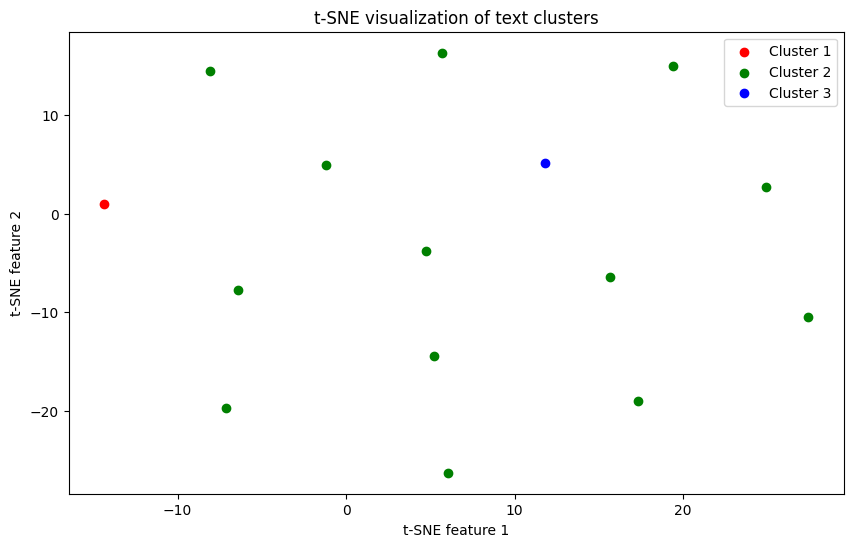

In [ ]:
# Perform K-Means clustering
num_clusters = 3  # You can change the number of clusters as needed
km = KMeans(n_clusters=num_clusters, random_state=0)
km.fit(tfidf_matrix)
clusters = km.labels_.tolist()

# Perform t-SNE visualization with adjusted perplexity
perplexity = min(30, len(processed_documents) - 1)
tsne = TSNE(n_components=2, random_state=0, perplexity=perplexity)
tsne_results = tsne.fit_transform(tfidf_matrix)

# Plot the t-SNE results
plt.figure(figsize=(10, 6))
colors = ['r', 'g', 'b']
for i in range(num_clusters):
    points = tsne_results[np.array(clusters) == i]
    plt.scatter(points[:, 0], points[:, 1], c=colors[i], label=f'Cluster {i + 1}')

plt.title('t-SNE visualization of text clusters')
plt.xlabel('t-SNE feature 1')
plt.ylabel('t-SNE feature 2')
plt.legend()
plt.show()

1.   Lemmatization



In [ ]:
import nltk
from nltk.stem import WordNetLemmatizer

# Sample paragraph
paragraph = """Thank you all so very much. Thank you to the Academy.
               Thank you to all of you in this room. I have to congratulate
               the other incredible nominees this year. The Revenant was
               the product of the tireless efforts of an unbelievable cast
               and crew. First off, to my brother in this endeavor, Mr. Tom
               Hardy. Tom, your talent on screen can only be surpassed by
               your friendship off screen … thank you for creating a
               transcendent cinematic experience. Thank you to everybody at
               Fox and New Regency … my entire team. I have to thank
               everyone from the very onset of my career … To my parents;
               none of this would be possible without you. And to my
               friends, I love you dearly; you know who you are. And lastly,
               I just want to say this: Making The Revenant was about
               man's relationship to the natural world. A world that we
               collectively felt in 2015 as the hottest year in recorded
               history. Our production needed to move to the southern
               tip of this planet just to be able to find snow. Climate
               change is real, it is happening right now. It is the most
               urgent threat facing our entire species, and we need to work
               collectively together and stop procrastinating. We need to
               support leaders around the world who do not speak for the
               big polluters, but who speak for all of humanity, for the
               indigenous people of the world, for the billions and
               billions of underprivileged people out there who would be
               most affected by this. For our children’s children, and
               for those people out there whose voices have been drowned
               out by the politics of greed. I thank you all for this
               amazing award tonight. Let us not take this planet for
               granted. I do not take tonight for granted. Thank you so very much."""


#Dependency Parsing

###The -> det -> fox
- Từ: "The"
- Quan hệ phụ thuộc: det (determiner - từ hạn định)
- Phụ thuộc vào: "fox"
- Giải thích: "The" là từ hạn định bổ nghĩa cho danh từ "fox".

###quick -> amod -> fox
- Từ: "quick"
- Quan hệ phụ thuộc: amod (adjectival modifier - bổ ngữ tính từ)
- Phụ thuộc vào: "fox"
- Giải thích: "quick" là tính từ bổ nghĩa cho danh từ "fox".

###brown -> amod -> fox
- Từ: "brown"
- Quan hệ phụ thuộc: amod (adjectival modifier - bổ ngữ tính từ)
- Phụ thuộc vào: "fox"
- Giải thích: "brown" là tính từ bổ nghĩa cho danh từ "fox".

###fox -> nsubj -> jumps
- Từ: "fox"
- Quan hệ phụ thuộc: nsubj (nominal subject - chủ ngữ danh từ)
- Phụ thuộc vào: "jumps"
- Giải thích: "fox" là chủ ngữ của động từ "jumps".

###jumps -> ROOT -> jumps
- Từ: "jumps"
- Quan hệ phụ thuộc: ROOT
- Phụ thuộc vào: (không có từ phụ thuộc vì đây là gốc của cây cú pháp)
- Giải thích: "jumps" là động từ chính và là gốc của câu.

###over -> prep -> jumps
- Từ: "over"
- Quan hệ phụ thuộc: prep (prepositional modifier - bổ ngữ giới từ)
- Phụ thuộc vào: "jumps"
- Giải thích: "over" là giới từ bổ nghĩa cho động từ "jumps".

###the -> det -> dog
- Từ: "the"
- Quan hệ phụ thuộc: det (determiner - từ hạn định)
- Phụ thuộc vào: "dog"
- Giải thích: "the" là từ hạn định bổ nghĩa cho danh từ "dog".

###lazy -> amod -> dog
- Từ: "lazy"
- Quan hệ phụ thuộc: amod (adjectival modifier - bổ ngữ tính từ)
- Phụ thuộc vào: "dog"
- Giải thích: "lazy" là tính từ bổ nghĩa cho danh từ "dog".

###dog -> pobj -> over
- Từ: "dog"
- Quan hệ phụ thuộc: pobj (prepositional object - tân ngữ của giới từ)
- Phụ thuộc vào: "over"
- Giải thích: "dog" là tân ngữ của giới từ "over".

In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")
doc = nlp("The quick brown fox jumps over the lazy dog")
for token in doc:
    print(f'{token.text} -> {token.dep_} -> {token.head.text}')


The -> det -> fox
quick -> amod -> fox
brown -> amod -> fox
fox -> nsubj -> jumps
jumps -> ROOT -> jumps
over -> prep -> jumps
the -> det -> dog
lazy -> amod -> dog
dog -> pobj -> over
